In [108]:
"""
Spam Message Detector
----------------------------------------
Minor Project - Mashine Learning using Python

Dataset : spam.csv

Tools used: Python, Pandas, Scikit-learn, Matplotlib
"""

'\nSpam Message Detector\n----------------------------------------\nMinor Project - Mashine Learning using Python\n\nDataset : spam.csv\n\nTools used: Python, Pandas, Scikit-learn, Matplotlib\n'

In [116]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle
import os

In [117]:
FILE_NAME = "spam.csv"
MODEL_FILE = "spam_model.pkl"
VECTORIZER_FILE = "vectorizer.pkl"

In [118]:
#-------------- Helper Function -----------------#

def load_data():
    
    df = pd.read_csv(FILE_NAME, encoding='latin1')
    df = df.dropna(subset=['label', 'message'])      
    df['label'] = df['label'].str.strip().str.lower() #original values -" Spam ", after .str.strip-"Spam"
    return df                                         #after .str.lower()-"spam"

In [119]:
def show_data_distribution(df):

    counts = df['label'].value_counts()  # total (ham) and (spam) message 
    print('\n-- Dataset Distribution --')
    print(counts.to_string())  # Ye un counts ko ache se readable text format me screen par print karta hai.
    print()

    plt.figure(figsize=(5,5))
    plt.pie(counts, labels=counts.index, autopct="%1.1f%%", startangle=90,
           colors=['lightgreen', 'lightcoral'])
    plt.title('Spam VS Ham Message Distribution')
    plt.axis('equal')
    plt.tight_layout()
    plt.savefig('spam_ham_distribution.png')  # image file
    print("Chart Saved as 'spam_ham_distribution.png'")
    plt.show()

In [120]:
#---------------- ML pipeline -------------------

def train_model():

    df = load_data()

    X = df['message']
    y = df['label'].map({'ham' : 0, 'spam' : 1})

    X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.25, random_state=42)

    vectorizer = TfidfVectorizer(stop_words='english')
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)

    model = MultinomialNB()
    model.fit(X_train_vec, y_train)

    y_pred = model.predict(X_test_vec)
    accuracy = accuracy_score(y_test, y_pred)

    print(f"\n--- Model Trained ---")
    print(f"Accuracy: {accuracy * 100:.2f}%")
    print("\nClassification Report: ")
    print(classification_report(y_test, y_pred,target_names=['ham','spam']))

    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix")
    print(cm)

    # save confusion matrix chart

    plt.figure(figsize=(5,5))
    plt.imshow(cm, cmap="Blues")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks([0, 1], ['Ham', 'Spam'])
    plt.yticks([0, 1], ['Ham', 'Spam'])

    for i in range(2):
        for j in range(2):
            plt.text(j, i, str(cm[i][j]), ha='center', va='center', fontsize=14)

    plt.colorbar()
    plt.tight_layout()
    plt.savefig("Confusion_matrix.png")
    print("Confusion matrix chart saved as 'confusion_matrix.png'")
    plt.show()

    # save model and vectorizer for later use
    with open(MODEL_FILE, 'wb') as f:
        pickle.dump(model, f)
    with open(VECTORIZER_FILE, 'wb') as f:
        pickle.dump(vectorizer, f)

    print(f"\nModel saved as '{MODEL_FILE}', vectorizer saved as '{VECTORIZER_FILE}'")

In [121]:
def predict_message():

    if not os.path.exists(MODEL_FILE) or not os.path.exists(VECTORIZER_FILE):
        print("\nModel not found. Please train the model first (Option 1).\n")
        return

    with open(MODEL_FILE, 'rb') as f:
        model = pickle.load(f)
    with open(VECTORIZER_FILE, 'rb') as f:
        vectorizer = pickle.load(f)

    message = input("\nEnter a message to check (Spam/Ham) : ")
    message_vec = vectorizer.transform([message])
    prediction = model.predict(message_vec)[0]
    probability = model.predict_proba(message_vec)[0]

    result = "SPAM" if prediction == 1 else "HAM (Not Spam)"
    confidence = probability[prediction] * 100

    print(f"\nPrediction: {result}")
    print(f"\nConfidence: {confidence:.2f}%\n")

          SPAM MESSAGE DETECTOR (ML)          
1. Trian Model (TF-IDF + Naive Bayes
2. Show Dataset Distribution (Pie Chart)
3. Test a message (Spam or Ham ?)
4. Exit



Enter Your Choice (1-4):  1



--- Model Trained ---
Accuracy: 96.63%

Classification Report: 
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98      1202
        spam       1.00      0.75      0.86       191

    accuracy                           0.97      1393
   macro avg       0.98      0.88      0.92      1393
weighted avg       0.97      0.97      0.96      1393

Confusion Matrix
[[1202    0]
 [  47  144]]
Confusion matrix chart saved as 'confusion_matrix.png'


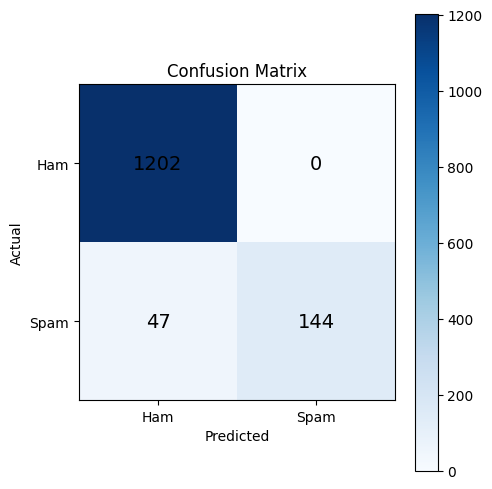


Model saved as 'spam_model.pkl', vectorizer saved as 'vectorizer.pkl'
          SPAM MESSAGE DETECTOR (ML)          
1. Trian Model (TF-IDF + Naive Bayes
2. Show Dataset Distribution (Pie Chart)
3. Test a message (Spam or Ham ?)
4. Exit



Enter Your Choice (1-4):  2



-- Dataset Distribution --
label
ham     4825
spam     747

Chart Saved as 'spam_ham_distribution.png'


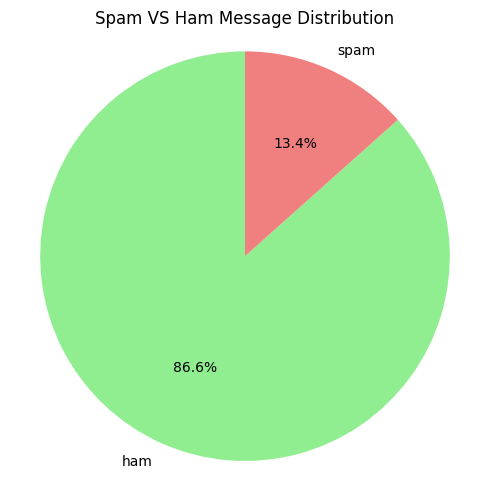

          SPAM MESSAGE DETECTOR (ML)          
1. Trian Model (TF-IDF + Naive Bayes
2. Show Dataset Distribution (Pie Chart)
3. Test a message (Spam or Ham ?)
4. Exit



Enter Your Choice (1-4):  4



Thanks you for using spam message detector. Goodbye!


In [124]:
def main():
    while True:
        print("=" * 46)
        print("          SPAM MESSAGE DETECTOR (ML)          ")
        print("=" * 46)
        print('1. Trian Model (TF-IDF + Naive Bayes')
        print('2. Show Dataset Distribution (Pie Chart)')
        print('3. Test a message (Spam or Ham ?)')
        print('4. Exit')

        choice = input('\nEnter Your Choice (1-4): ')

        if choice == '1':
            train_model()
        elif choice == '2':
            show_data_distribution(df)
        elif choice == '3':
            predict_message()
        elif choice == '4':
            print('\nThanks you for using spam message detector. Goodbye!')
            break
        else:
            print("\nInvalid Choice. Please enter a number beetween 1-4.\n")

if __name__ == "__main__":
    main()